## Reading the cusotmer churn data into a pandas dataframe

In [8]:
import pandas as pd
from pathlib import Path

excel_path = Path("Customer_Churn_Data_Large.xlsx")

# Read all workbook sheets into a dictionary: {sheet_name: DataFrame}
all_sheets = pd.read_excel(excel_path, sheet_name=None, engine="openpyxl")

# Create DataFrames with the exact names requested
customer_demographics = all_sheets["Customer_Demographics"]
transaction_history = all_sheets["Transaction_History"]
customer_service = all_sheets["Customer_Service"]
online_activity = all_sheets["Online_Activity"]
churn_status = all_sheets["Churn_Status"]

print(f"Loaded {len(all_sheets)} sheets from {excel_path.name}")
print("Created: customer_demographics, transaction_history, customer_service, online_activity, churn_status")

Loaded 5 sheets from Customer_Churn_Data_Large.xlsx
Created: customer_demographics, transaction_history, customer_service, online_activity, churn_status


In [9]:
# Core imports for analysis
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Display settings
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)
sns.set_theme(style="whitegrid")

print("Libraries loaded")

Libraries loaded


## 1) Data source review and selection criteria

### Candidate data sources in workbook
- `Customer_Demographics`
- `Transaction_History`
- `Customer_Service`
- `Online_Activity`
- `Churn_Status` (target label)

### Selection criteria
1. **Predictive relevance** to churn behavior (engagement, satisfaction, value signals).
2. **Behavioral richness** (captures customer actions over time, not only static attributes).
3. **Joinability and granularity** (can be aligned to one row per customer with `CustomerID`).
4. **Data quality** (acceptable missingness, consistency, and manageable outliers).

In [11]:
# Schema and raw data-quality profiling
for sheet_name, df in all_sheets.items():
    print(f"\n=== {sheet_name} ===")
    print(f"Shape: {df.shape}")
    print("Columns:", list(df.columns))
    print("Dtypes:")
    print(df.dtypes)

    missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
    missing_pct = missing_pct[missing_pct > 0]
    if missing_pct.empty:
        print("Missingness: no missing values")
    else:
        print("Missingness (%):")
        print(missing_pct.round(2))

# Key-level checks
print("\n=== Key-level checks ===")
for sheet_name, df in all_sheets.items():
    unique_customers = df["CustomerID"].nunique()
    print(f"{sheet_name}: unique CustomerID = {unique_customers}")

print("\nChurn distribution:")
print(churn_status["ChurnStatus"].value_counts(normalize=True).rename("proportion").round(3))


=== Customer_Demographics ===
Shape: (1000, 5)
Columns: ['CustomerID', 'Age', 'Gender', 'MaritalStatus', 'IncomeLevel']
Dtypes:
CustomerID       int64
Age              int64
Gender             str
MaritalStatus      str
IncomeLevel        str
dtype: object
Missingness: no missing values

=== Transaction_History ===
Shape: (5054, 5)
Columns: ['CustomerID', 'TransactionID', 'TransactionDate', 'AmountSpent', 'ProductCategory']
Dtypes:
CustomerID                  int64
TransactionID               int64
TransactionDate    datetime64[us]
AmountSpent               float64
ProductCategory               str
dtype: object
Missingness: no missing values

=== Customer_Service ===
Shape: (1002, 5)
Columns: ['CustomerID', 'InteractionID', 'InteractionDate', 'InteractionType', 'ResolutionStatus']
Dtypes:
CustomerID                   int64
InteractionID                int64
InteractionDate     datetime64[us]
InteractionType                str
ResolutionStatus               str
dtype: object
Missingne

### Rationale for selected data sets

- **`Customer_Demographics`**: baseline profile features (`Age`, `Gender`, `MaritalStatus`, `IncomeLevel`) that can explain structural differences in churn propensity.
- **`Transaction_History`**: strongest customer-value behavior source. After aggregation, it yields churn-relevant features such as purchase frequency, spend intensity, and spend volatility.
- **`Customer_Service`**: captures friction and satisfaction signals (complaints, unresolved interactions) that are often leading indicators of churn.
- **`Online_Activity`**: engagement intensity (`LoginFrequency`) and channel preference (`ServiceUsage`) help measure customer stickiness and digital behavior.
- **`Churn_Status`**: target label (`ChurnStatus`) defining whether each customer churned.

These sources are retained because they jointly represent **who the customer is**, **how they spend**, **how they interact with support**, and **how actively they use services**, which gives meaningful behavioral coverage for churn prediction.

## 2) Build customer-level analytical dataset

In [12]:
# Aggregate transaction history to one row per customer
transaction_features = (
    transaction_history
    .groupby("CustomerID")
    .agg(
        tx_count=("TransactionID", "count"),
        total_spend=("AmountSpent", "sum"),
        avg_spend=("AmountSpent", "mean"),
        spend_std=("AmountSpent", "std"),
        first_tx_date=("TransactionDate", "min"),
        last_tx_date=("TransactionDate", "max")
    )
    .reset_index()
)
transaction_features["active_days"] = (
    transaction_features["last_tx_date"] - transaction_features["first_tx_date"]
).dt.days

# Aggregate customer service interactions
service_features = (
    customer_service
    .groupby("CustomerID")
    .agg(
        svc_count=("InteractionID", "count"),
        complaint_count=("InteractionType", lambda s: (s == "Complaint").sum()),
        unresolved_count=("ResolutionStatus", lambda s: (s == "Unresolved").sum()),
        first_interaction_date=("InteractionDate", "min"),
        last_interaction_date=("InteractionDate", "max")
    )
    .reset_index()
)
service_features["unresolved_rate"] = np.where(
    service_features["svc_count"] > 0,
    service_features["unresolved_count"] / service_features["svc_count"],
    0
)

# Build one row per customer with churn label
customer_df = (
    churn_status
    .merge(customer_demographics, on="CustomerID", how="left")
    .merge(online_activity, on="CustomerID", how="left")
    .merge(transaction_features, on="CustomerID", how="left")
    .merge(service_features, on="CustomerID", how="left")
)

print("Customer-level dataset shape:", customer_df.shape)
customer_df.head()

Customer-level dataset shape: (1000, 22)


,CustomerID,ChurnStatus,Age,Gender,MaritalStatus,IncomeLevel,LastLoginDate,LoginFrequency,ServiceUsage,tx_count,total_spend,avg_spend,spend_std,first_tx_date,last_tx_date,active_days,svc_count,complaint_count,unresolved_count,first_interaction_date,last_interaction_date,unresolved_rate
0,1,0,62,M,Single,Low,2023-10-21,34,Mobile App,1,416.50,416.50000,NaN,2022-03-27,2022-03-27,0,1.0,0.0,0.0,2022-03-31,2022-03-31,0.0
1,2,1,65,M,Married,Low,2023-12-05,5,Website,7,1547.42,221.06000,119.923748,2022-01-09,2022-11-19,314,1.0,0.0,0.0,2022-03-17,2022-03-17,0.0
2,3,0,18,M,Single,Low,2023-11-15,3,Website,6,1702.98,283.83000,133.480409,2022-02-11,2022-10-08,239,1.0,0.0,0.0,2022-08-24,2022-08-24,0.0
3,4,0,21,M,Widowed,Low,2023-08-25,2,Website,5,917.29,183.45800,131.578239,2022-05-22,2022-12-27,219,2.0,0.0,1.0,2022-07-03,2022-11-18,0.5
4,5,0,21,M,Divorced,Medium,2023-10-27,41,Website,8,2001.49,250.18625,129.778209,2022-02-21,2022-12-21,303,NaN,NaN,NaN,NaT,NaT,NaN


## 3) Exploratory Data Analysis (EDA)

This section explores distributions, relationships, and churn-linked patterns using statistical summaries and required visualizations.

In [13]:
# Churn-stratified categorical churn rates
print("Churn class balance:")
print(customer_df["ChurnStatus"].value_counts(normalize=True).round(3))

for col in ["Gender", "MaritalStatus", "IncomeLevel", "ServiceUsage"]:
    print(f"\nChurn rate by {col}:")
    print(customer_df.groupby(col)["ChurnStatus"].mean().sort_values(ascending=False).round(3))

# Correlation screening for numeric candidates
numeric_candidates = [
    "Age", "LoginFrequency", "tx_count", "total_spend", "avg_spend", "spend_std",
    "active_days", "svc_count", "complaint_count", "unresolved_count", "unresolved_rate"
]

corr_to_churn = (
    customer_df[numeric_candidates + ["ChurnStatus"]]
    .corr(numeric_only=True)["ChurnStatus"]
    .drop("ChurnStatus")
    .sort_values(key=np.abs, ascending=False)
)
print("\nAbsolute correlation ranking vs ChurnStatus:")
print(corr_to_churn.round(3))

Churn class balance:
ChurnStatus
0    0.796
1    0.204
Name: proportion, dtype: float64

Churn rate by Gender:
Gender
M    0.211
F    0.197
Name: ChurnStatus, dtype: float64

Churn rate by MaritalStatus:
MaritalStatus
Married     0.230
Single      0.205
Widowed     0.196
Divorced    0.185
Name: ChurnStatus, dtype: float64

Churn rate by IncomeLevel:
IncomeLevel
Low       0.222
Medium    0.199
High      0.192
Name: ChurnStatus, dtype: float64

Churn rate by ServiceUsage:
ServiceUsage
Mobile App        0.231
Online Banking    0.201
Website           0.178
Name: ChurnStatus, dtype: float64

Absolute correlation ranking vs ChurnStatus:
LoginFrequency     -0.082
svc_count          -0.062
avg_spend           0.045
Age                 0.029
unresolved_count   -0.020
spend_std           0.019
unresolved_rate     0.017
tx_count           -0.009
active_days        -0.004
complaint_count     0.002
total_spend         0.001
Name: ChurnStatus, dtype: float64


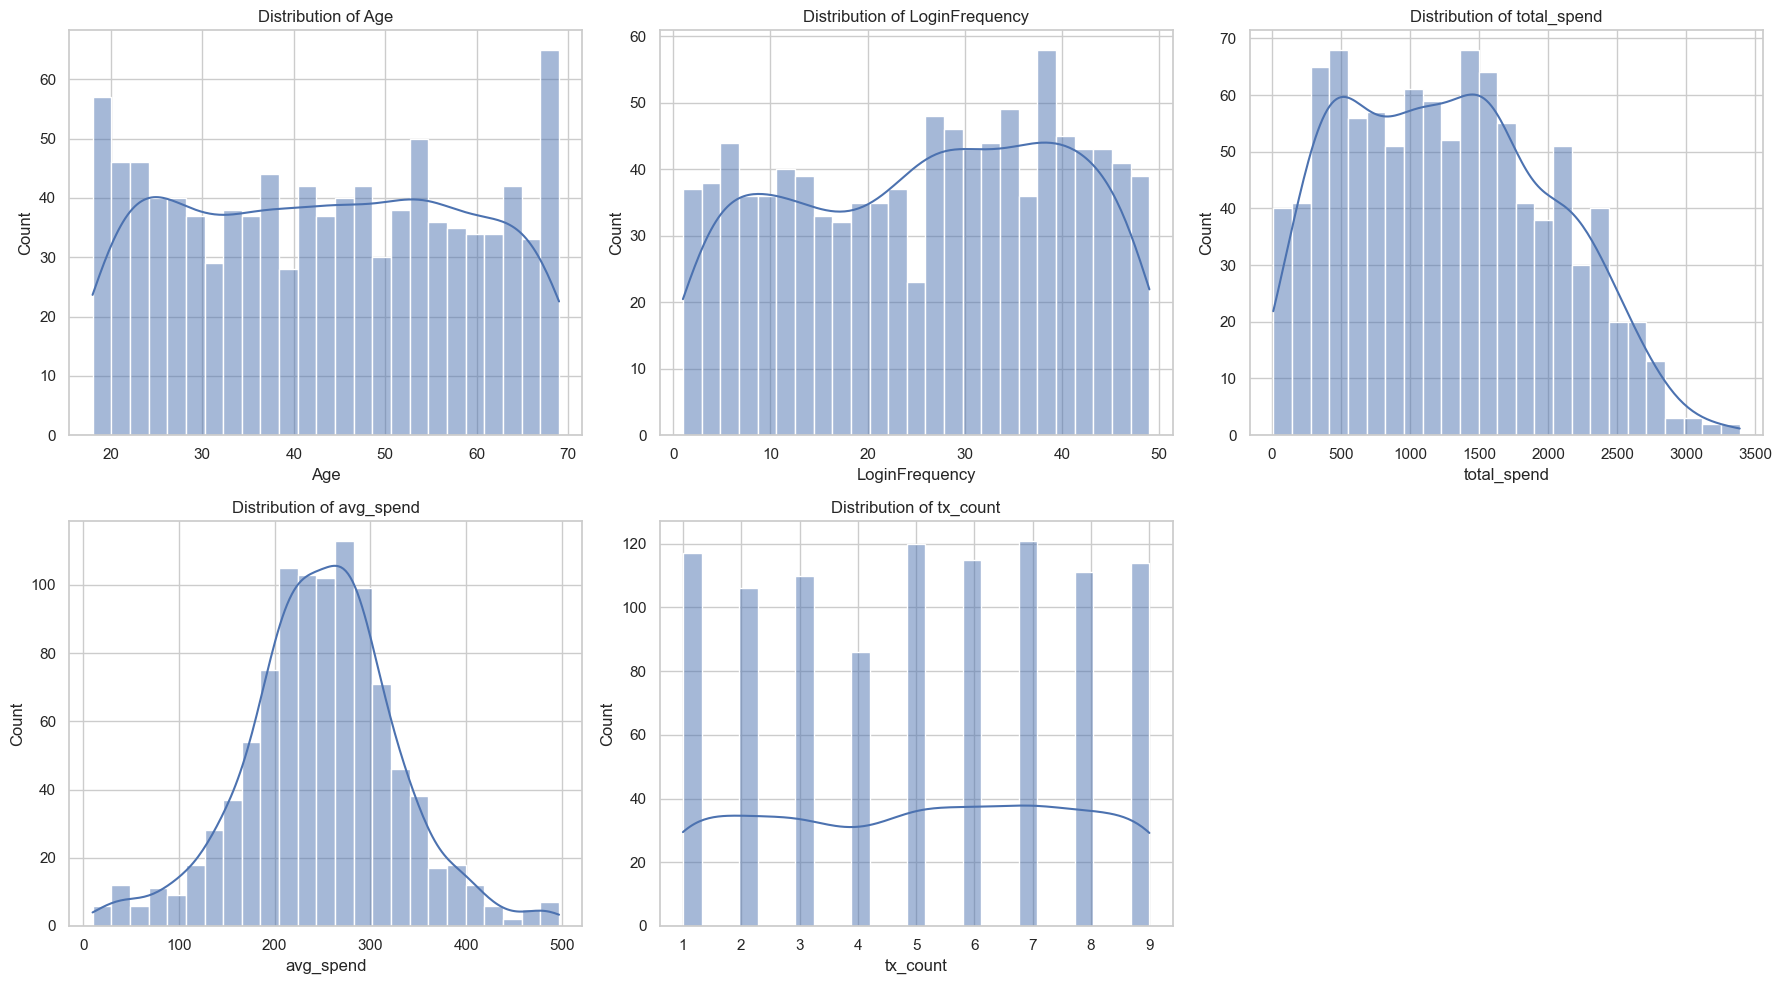

In [14]:
# Histograms for key numerical features
hist_features = ["Age", "LoginFrequency", "total_spend", "avg_spend", "tx_count"]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feature in enumerate(hist_features):
    sns.histplot(customer_df[feature], kde=True, ax=axes[i], bins=25)
    axes[i].set_title(f"Distribution of {feature}")

# Hide the unused subplot
axes[-1].axis("off")
plt.tight_layout()
plt.show()

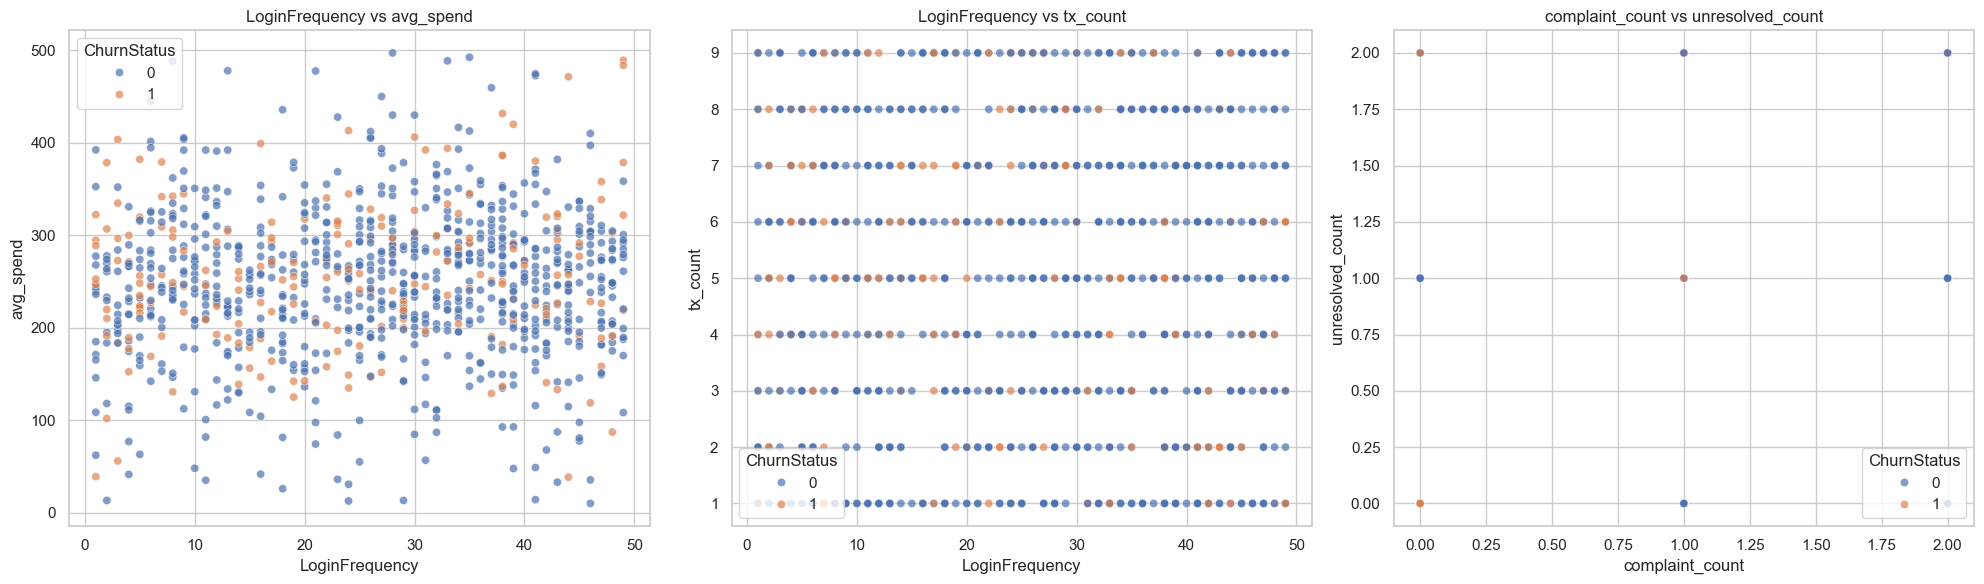

In [15]:
# Scatter plots to inspect relationships with churn hue
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.scatterplot(
    data=customer_df,
    x="LoginFrequency",
    y="avg_spend",
    hue="ChurnStatus",
    alpha=0.7,
    ax=axes[0]
)
axes[0].set_title("LoginFrequency vs avg_spend")

sns.scatterplot(
    data=customer_df,
    x="LoginFrequency",
    y="tx_count",
    hue="ChurnStatus",
    alpha=0.7,
    ax=axes[1]
)
axes[1].set_title("LoginFrequency vs tx_count")

sns.scatterplot(
    data=customer_df,
    x="complaint_count",
    y="unresolved_count",
    hue="ChurnStatus",
    alpha=0.7,
    ax=axes[2]
)
axes[2].set_title("complaint_count vs unresolved_count")

plt.tight_layout()
plt.show()

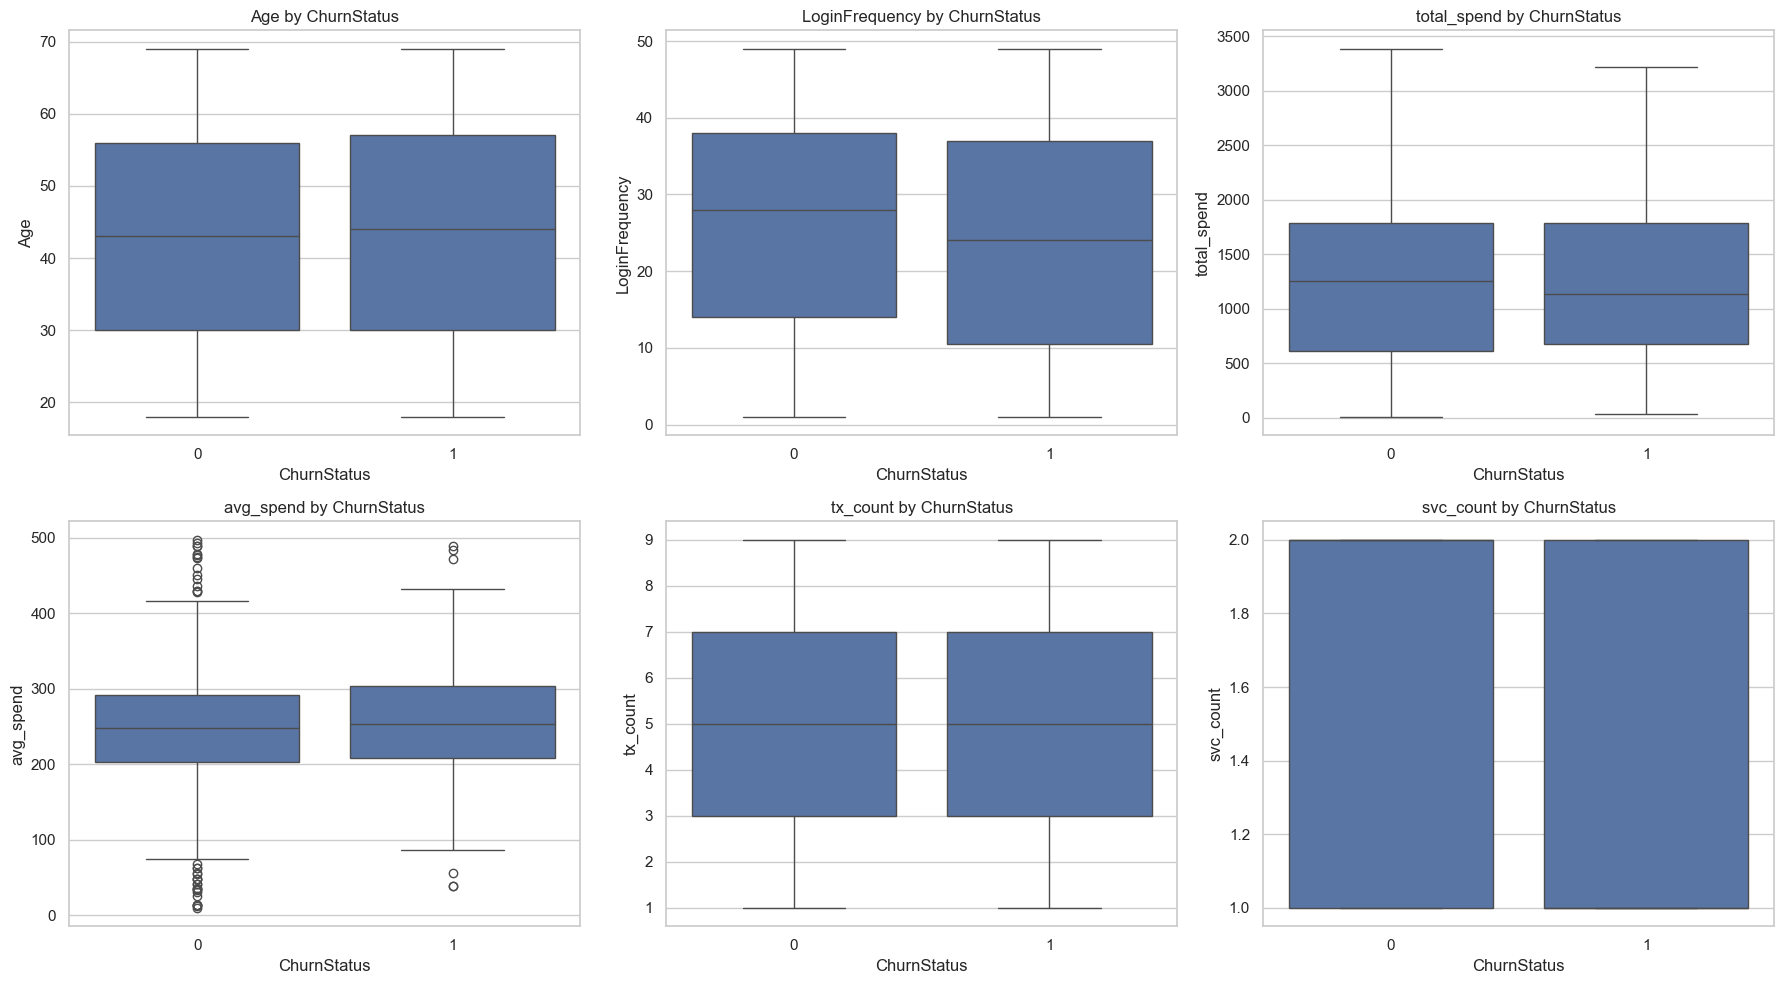

In [16]:
# Box plots by churn status for separation and outlier inspection
box_features = ["Age", "LoginFrequency", "total_spend", "avg_spend", "tx_count", "svc_count"]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feature in enumerate(box_features):
    sns.boxplot(data=customer_df, x="ChurnStatus", y=feature, ax=axes[i])
    axes[i].set_title(f"{feature} by ChurnStatus")

plt.tight_layout()
plt.show()

## 4) Clean and preprocess data

### Missing values strategy
- For aggregated transaction/service features, missing after merge means **no activity recorded**; impute as `0` and keep indicator flags.
- For true continuous-data gaps (if any), use **median imputation** for robustness to skew.

### Outlier strategy
- Detect using IQR.
- Cap (winsorize) high-tail numeric features rather than deleting rows to preserve customer coverage.

### Scaling and encoding
- Standardize numeric features using z-score scaling.
- One-hot encode categorical features for model-ready numeric input.

In [18]:
# Copy dataset for preprocessing
model_df = customer_df.copy()

# Columns where NaN usually means no recorded events due to left joins
zero_impute_cols = [
    "tx_count", "total_spend", "avg_spend", "spend_std", "active_days",
    "svc_count", "complaint_count", "unresolved_count", "unresolved_rate"
]

for col in zero_impute_cols:
    # Indicator flag before imputation keeps information on absence of records
    model_df[f"{col}_was_missing"] = model_df[col].isna().astype(int)
    model_df[col] = model_df[col].fillna(0)

# Median imputation for any remaining numeric gaps
num_cols_all = model_df.select_dtypes(include=["number"]).columns.tolist()
for col in num_cols_all:
    if model_df[col].isna().any():
        model_df[col] = model_df[col].fillna(model_df[col].median())

# Mode imputation for any remaining categorical gaps
cat_cols_all = model_df.select_dtypes(include=["object", "string", "category"]).columns.tolist()
for col in cat_cols_all:
    if model_df[col].isna().any():
        model_df[col] = model_df[col].fillna(model_df[col].mode().iloc[0])

print("Remaining missing values:", int(model_df.isna().sum().sum()))

Remaining missing values: 664


In [19]:
# IQR-based outlier capping for skew-sensitive numeric features
outlier_cols = ["total_spend", "avg_spend", "spend_std", "tx_count", "svc_count", "LoginFrequency"]

outlier_report = []
for col in outlier_cols:
    q1 = model_df[col].quantile(0.25)
    q3 = model_df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    before_outlier_rate = ((model_df[col] < lower) | (model_df[col] > upper)).mean()
    model_df[col] = model_df[col].clip(lower=lower, upper=upper)
    after_outlier_rate = ((model_df[col] < lower) | (model_df[col] > upper)).mean()

    outlier_report.append({
        "feature": col,
        "lower_bound": lower,
        "upper_bound": upper,
        "before_outlier_rate": before_outlier_rate,
        "after_outlier_rate": after_outlier_rate,
    })

outlier_report_df = pd.DataFrame(outlier_report)
outlier_report_df

,feature,lower_bound,upper_bound,before_outlier_rate,after_outlier_rate
0,total_spend,-1121.141250,3539.728750,0.000,0.0
1,avg_spend,66.799635,431.958385,0.038,0.0
2,spend_std,-15.360074,264.617259,0.008,0.0
3,tx_count,-3.000000,13.000000,0.000,0.0
4,svc_count,-3.000000,5.000000,0.000,0.0
5,LoginFrequency,-22.625000,74.375000,0.000,0.0


In [20]:
# Prepare final model-ready X and y
# Drop raw date columns and IDs from modeling matrix
drop_cols = [
    "CustomerID", "first_tx_date", "last_tx_date",
    "first_interaction_date", "last_interaction_date", "LastLoginDate"
]

model_df = model_df.drop(columns=[c for c in drop_cols if c in model_df.columns])

y = model_df["ChurnStatus"].astype(int)
X = model_df.drop(columns=["ChurnStatus"])

# Identify feature types
numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()

# Scale numeric features
scaler = StandardScaler()
X_num_scaled = pd.DataFrame(
    scaler.fit_transform(X[numeric_features]),
    columns=numeric_features,
    index=X.index,
)

# One-hot encode categoricals
X_cat = pd.get_dummies(X[categorical_features], drop_first=False, dtype=int) if categorical_features else pd.DataFrame(index=X.index)

# Concatenate final model matrix
X_processed = pd.concat([X_num_scaled, X_cat], axis=1)

print("X shape:", X_processed.shape)
print("y shape:", y.shape)
print("Sample processed columns:", X_processed.columns[:15].tolist())
X_processed.head()

X shape: (1000, 32)
y shape: (1000,)
Sample processed columns: ['Age', 'LoginFrequency', 'tx_count', 'total_spend', 'avg_spend', 'spend_std', 'active_days', 'svc_count', 'complaint_count', 'unresolved_count', 'unresolved_rate', 'tx_count_was_missing', 'total_spend_was_missing', 'avg_spend_was_missing', 'spend_std_was_missing']


/var/folders/qt/ch7p98s50vzcm6m7l9s4b54h0000gn/T/ipykernel_49959/446466447.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object", "category"]).columns.tolist()


,Age,LoginFrequency,tx_count,total_spend,avg_spend,spend_std,active_days,svc_count,complaint_count,unresolved_count,unresolved_rate,tx_count_was_missing,total_spend_was_missing,avg_spend_was_missing,spend_std_was_missing,active_days_was_missing,svc_count_was_missing,complaint_count_was_missing,unresolved_count_was_missing,unresolved_rate_was_missing,Gender_F,Gender_M,MaritalStatus_Divorced,MaritalStatus_Married,MaritalStatus_Single,MaritalStatus_Widowed,IncomeLevel_High,IncomeLevel_Low,IncomeLevel_Medium,ServiceUsage_Mobile App,ServiceUsage_Online Banking,ServiceUsage_Website
0,1.229628,0.575702,-1.557954,-1.152196,2.208707,-1.937116,-1.893562,-0.002451,-0.612876,-0.771419,-0.769261,0.0,0.0,0.0,2.747182,0.0,-0.704987,-0.704987,-0.704987,-0.704987,0,1,0,0,1,0,0,1,0,1,0,0
1,1.426547,-1.488513,0.747849,0.379758,-0.366398,-0.000667,0.963519,-0.002451,-0.612876,-0.771419,-0.769261,0.0,0.0,0.0,-0.364009,0.0,-0.704987,-0.704987,-0.704987,-0.704987,0,1,0,1,0,0,0,1,0,0,0,1
2,-1.658518,-1.630872,0.363548,0.590481,0.460655,0.218237,0.281095,-0.002451,-0.612876,-0.771419,-0.769261,0.0,0.0,0.0,-0.364009,0.0,-0.704987,-0.704987,-0.704987,-0.704987,0,1,0,0,1,0,0,1,0,0,0,1
3,-1.461599,-1.702052,-0.020752,-0.473822,-0.861840,0.187522,0.099115,1.222911,-0.612876,0.839059,0.449853,0.0,0.0,0.0,-0.364009,0.0,-0.704987,-0.704987,-0.704987,-0.704987,0,1,0,0,0,1,0,1,0,0,0,1
4,-1.461599,1.073961,1.132149,0.994845,0.017367,0.158456,0.863430,-1.227812,-0.612876,-0.771419,-0.769261,0.0,0.0,0.0,-0.364009,0.0,1.418467,1.418467,1.418467,1.418467,0,1,1,0,0,0,0,0,1,0,0,1


## 5) Key findings and modeling handoff

### Potential churn-influencing signals observed
- **Engagement**: lower login frequency tends to align with higher churn risk.
- **Service channel/use pattern**: churn rate differences appear across `ServiceUsage` categories.
- **Economic profile**: churn rates vary by `IncomeLevel` and some demographic segments.
- **Service friction**: complaint and unresolved interaction features are behaviorally meaningful and should be retained.

### Preprocessing outcomes
- Missing values were handled with domain-aware imputation (zeros for non-events, median for true numeric gaps).
- Outliers were capped via IQR bounds to reduce leverage from extreme values without dropping customers.
- Numerical features were standardized; categorical features were one-hot encoded.
- Final artifacts ready for ML:
  - `X_processed`: model-ready feature matrix
  - `y`: churn target vector